# LNA Non-Linear Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
from rfmodel.core.units import w_to_dbm
from rfmodel.meas.spectrum_analyser import spectrum_analyser
from rfmodel.plot_utils.spectrum_plot import plot_top_spectrum
from scipy.signal import hilbert
import rfmodel.rf.registry
cfg = load_yaml(r".\pipeline_LNA_demo.yaml")
pipe = pipeline_from_config(cfg)


# Note on power after Hilbert transform:
The analytic signal $x_a(t) = x(t) + j\cdot Hilbert{x(t)}$ removes the negative-frequency components and doubles the positive-frequency components. A real cosine
$$cos(\omega t) = 0.5·e^{j\omega t} + 0.5·e^{-j\omega t}$$
becomes $e^{j\omega t}$ in analytic form. As a result, the mean-square value changes:
$$E[|x_a(t)|^2] = 2 \cdot E[x^2(t)]$$

i.e., the analytic signal has twice the power of the original real signal. This is expected and reflects the one-sided spectrum representation. If power equivalence with the real RF signal is desired, scale the analytic (or complex envelope) signal by 1/sqrt(2).

In [ ]:
fs = 5_000_000
t = np.arange(0, 2e-3, 1/fs)

fc = 1e6
f_offset1 = 50_000
f_offset2 = 120_000

# two RF tones (real signal)
rf1 = np.cos(2*np.pi*(fc + f_offset1)*t)
rf2 = np.cos(2*np.pi*(fc + f_offset2)*t)
rf = rf1 + rf2
rf_analytic = hilbert(rf)  # finding the analytical signal
complex_envelope = rf_analytic * np.exp(-1j * 2*np.pi*fc*t)

P_tone1_real = np.mean(rf1**2)          
P_tone2_real = np.mean(rf2**2)        
P_total_real = np.mean(rf**2)
P_ce_total   = np.mean(np.abs(complex_envelope)**2)  

print(f"Per-tone real power:           {P_tone1_real:.4f}  W")
print(f"Total real power (both tones): {P_total_real:.4f}  W")
print(f"Total CE power  mean(|x̃|²):   {P_ce_total:.4f}  W")
print(f"CE / 4 :         {P_ce_total/4:.4f}  W")
print()
print(f"CE/4 == per-tone real: {np.isclose(P_ce_total/4, P_tone1_real, rtol=1e-3)}")

print(f"CE / 4 :         {P_ce_total/4:.4f}  W")
print()
print(f"CE/4 == per-tone real: {np.isclose(P_ce_total/4, P_tone1_real, rtol=1e-3)}")

combined_two_tone = Signal(
    x=complex_envelope,
    fs_hz=fs,
    fc_hz=fc,
    meta={
        "name": f"combined two tone test (fs = {fs * 1e-6} MHz)",
        "Carrier": f"{fc*1e-6} MHz",
        "meta": f"Original Seperation of tones: {(f_offset2 - f_offset1) * 1e-3} kHz",
    },
)
combined_two_tone.meta

Per-tone real power:           0.5000  W
Total real power (both tones): 1.0000  W
Total CE power  mean(|x̃|²):   2.0000  W
CE / 4 :         0.5000  W

CE/4 == per-tone real: True
CE / 4  (our formula):         0.5000  W

CE/4 == per-tone real: True


{'name': 'combined two tone test (fs = 5.0 MHz)',
 'Carrier': '1.0 MHz',
 'meta': 'Original Seperation of tones: 70.0 kHz'}

## Running pipeline and extracting IIP3

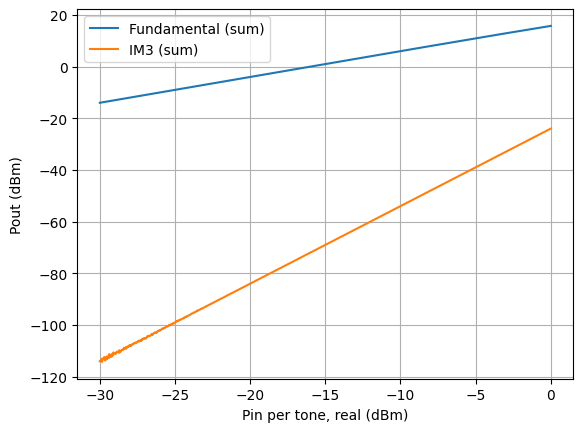

In [3]:
Pin0_W = np.mean(np.abs(combined_two_tone.x)**2) / 4   # per-tone real power
Pin0_dBm = w_to_dbm(Pin0_W)

Pin_dBm_sweep = np.linspace(-30, 0, 1000)
scale_factors = 10 ** ((Pin_dBm_sweep - Pin0_dBm) / 20.0)

target_f_im3_1 = 2 * f_offset1 - f_offset2
target_f_im3_2 = 2 * f_offset2 - f_offset1



Pout_ideal_list_dbm = []
Pout_IM3_list_dbm = []

for k in scale_factors:
    sweep_signal = combined_two_tone.copy_with(
        x=k * combined_two_tone.x,
        meta={"scale_factor": float(k)},
    )

    sig_out, _ = pipe.run(sweep_signal)
    lna = pipe.blocks[0]

    S_out, freqs = spectrum_analyser(sig_out.x, fs)
    idx_im3_1 = np.argmin(np.abs(freqs - target_f_im3_1))
    idx_im3_2 = np.argmin(np.abs(freqs - target_f_im3_2))

    idx_fund_1 = np.argmin(np.abs(freqs - f_offset1))
    idx_fund_2 = np.argmin(np.abs(freqs - f_offset2))

    ideal_w = S_out[idx_fund_1] + S_out[idx_fund_2]
    IM3_w = S_out[idx_im3_1] + S_out[idx_im3_2]


    Pout_ideal_dBm = w_to_dbm(ideal_w)
    Pout_IM3_dBm   = w_to_dbm(IM3_w)

    Pout_ideal_list_dbm.append(Pout_ideal_dBm)
    Pout_IM3_list_dbm.append(Pout_IM3_dBm)

Pout_ideal_array_dbm = np.array(Pout_ideal_list_dbm)
Pout_IM3_array_dbm   = np.array(Pout_IM3_list_dbm)

plt.plot(Pin_dBm_sweep, Pout_ideal_array_dbm, label="Fundamental (sum)")
plt.plot(Pin_dBm_sweep, Pout_IM3_array_dbm, label="IM3 (sum)")
plt.xlabel("Pin per tone, real (dBm)")
plt.ylabel("Pout (dBm)")
plt.grid(True)
plt.legend()
plt.show()

IIM3: 19.90619268431847
error in intercept point -0.09380731568153067 dBm
Fundamental slope: 0.9998 dB/dB
IM3 slope: 3.0042 dB/dB


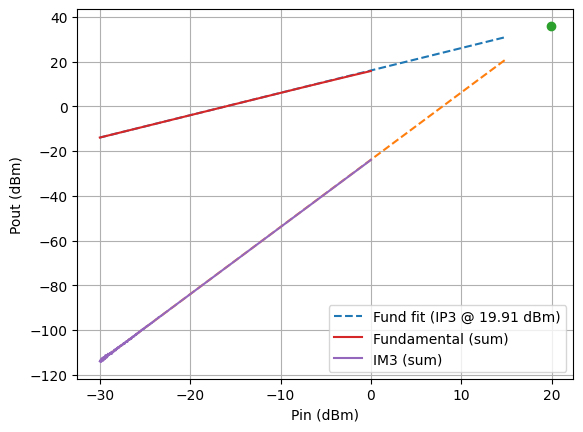

In [4]:
fit_min = -30
fit_max = -20
mask = (Pin_dBm_sweep >= fit_min) & (Pin_dBm_sweep <= fit_max)

m_f, b_f = np.polyfit(Pin_dBm_sweep[mask], Pout_ideal_array_dbm[mask], 1)
m_i, b_i = np.polyfit(Pin_dBm_sweep[mask], Pout_IM3_array_dbm[mask], 1)

x_cross = (b_i - b_f) / (m_f - m_i)
y_cross = m_f * x_cross + b_f

x_extension = 15 

x_min = np.min(Pin_dBm_sweep)
x_max = np.max(Pin_dBm_sweep) + x_extension
x_ext = np.linspace(x_min, x_max, 400)


# ---- plot ----
plt.plot(x_ext, m_f * x_ext + b_f, '--', label=f'Fund fit (IP3 @ {x_cross:.2f} dBm)')
plt.plot(x_ext, m_i * x_ext + b_i, '--')

plt.plot(x_cross, y_cross, 'o')
plt.plot(Pin_dBm_sweep, Pout_ideal_array_dbm, label="Fundamental (sum)")
plt.plot(Pin_dBm_sweep, Pout_IM3_array_dbm, label="IM3 (sum)")
print(f'IIM3: {x_cross}')
print(f'error in intercept point {x_cross-cfg["pipeline"][0]["params"]["IP3_dbm"]} dBm')
print(f"Fundamental slope: {m_f:.4f} dB/dB")
print(f"IM3 slope: {m_i:.4f} dB/dB")
plt.xlabel("Pin (dBm)")
plt.ylabel("Pout (dBm)")
plt.grid(True)
plt.legend()
plt.show()